In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def f2(t, y):
    return y * (np.sin(t))**3

def exact2(t):
    return np.exp(-np.cos(t) + ((np.cos(t))**3)/3 + 2/3)

In [11]:
def euler_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        y[i+1] = y[i] + h * f(t[i], y[i])
        t[i+1] = t[i] + h
    return t, y

In [12]:
def heun_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        k1 = f(t[i], y[i])
        y_pred = y[i] + h * k1
        k2 = f(t[i] + h, y_pred)
        y[i+1] = y[i] + (h / 2.0) * (k1 + k2)
        t[i+1] = t[i] + h
    return t, y

In [13]:
h_list2 = [0.1, 0.005, 0.001, 0.0005, 0.0001]
t0b, y0b, tendb = 0, 1, 5

euler_results2 = {}
heun_results2 = {}

for h in h_list2:
    te, ye = euler_method(f2, t0b, y0b, h, tendb)
    th, yh = heun_method(f2, t0b, y0b, h, tendb)
    
    yexact_e = exact2(te)
    yexact_h = exact2(th)
    
    err_e = np.abs(yexact_e - ye)
    err_h = np.abs(yexact_h - yh)
    
    euler_results2[h] = (te, ye, yexact_e, err_e)
    heun_results2[h] = (th, yh, yexact_h, err_h)

In [14]:
for h in h_list2:
    te, ye, yexact_e, err_e = euler_results2[h]
    print(f"\n--- Euler Method Table (h = {h}) ---")
    print(f"{'t':>8}{'Euler y':>15}{'Exact y':>15}{'Error':>15}")
    if len(te) <= 20:
        for i in range(len(te)):
            print(f"{te[i]:8.4f}{ye[i]:15.6f}{yexact_e[i]:15.6f}{err_e[i]:15.6f}")
    else:
        for i in range(10):
            print(f"{te[i]:8.4f}{ye[i]:15.6f}{yexact_e[i]:15.6f}{err_e[i]:15.6f}")
        print("...")
        for i in range(len(te)-10, len(te)):
            print(f"{te[i]:8.4f}{ye[i]:15.6f}{yexact_e[i]:15.6f}{err_e[i]:15.6f}")

for h in h_list2:
    th, yh, yexact_h, err_h = heun_results2[h]
    print(f"\n--- Heun Method Table (h = {h}) ---")
    print(f"{'t':>8}{'Heun y':>15}{'Exact y':>15}{'Error':>15}")
    if len(th) <= 20:
        for i in range(len(th)):
            print(f"{th[i]:8.4f}{yh[i]:15.6f}{yexact_h[i]:15.6f}{err_h[i]:15.6f}")
    else:
        for i in range(10):
            print(f"{th[i]:8.4f}{yh[i]:15.6f}{yexact_h[i]:15.6f}{err_h[i]:15.6f}")
        print("...")
        for i in range(len(th)-10, len(th)):
            print(f"{th[i]:8.4f}{yh[i]:15.6f}{yexact_h[i]:15.6f}{err_h[i]:15.6f}")


--- Euler Method Table (h = 0.1) ---
       t        Euler y        Exact y          Error
  0.0000       1.000000       1.000000       0.000000
  0.1000       1.000000       1.000025       0.000025
  0.2000       1.000100       1.000395       0.000295
  0.3000       1.000884       1.001967       0.001083
  0.4000       1.003467       1.006086       0.002619
  0.5000       1.009393       1.014478       0.005086
  0.6000       1.020516       1.029148       0.008632
  0.7000       1.038887       1.052286       0.013398
  0.8000       1.066663       1.086202       0.019539
  0.9000       1.106039       1.133284       0.027245
...
  4.1000       3.177621       3.248453       0.070833
  4.2000       3.003519       3.057656       0.054137
  4.3000       2.804660       2.846256       0.041596
  4.4000       2.588983       2.623012       0.034029
  4.5000       2.365885       2.397293       0.031408
  4.6000       2.144890       2.177874       0.032984
  4.7000       1.934435       1.972013  

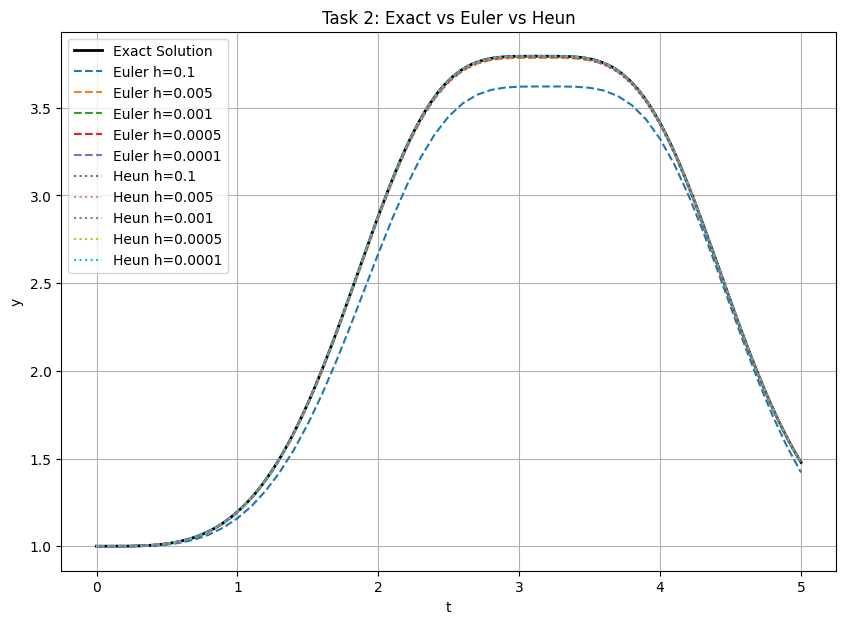

In [15]:
plt.figure(figsize=(10, 7))
tt2 = np.linspace(t0b, tendb, 1000)
plt.plot(tt2, exact2(tt2), 'k-', linewidth=2, label='Exact Solution')

for h in h_list2:
    te, ye, _, _ = euler_results2[h]
    plt.plot(te, ye, '--', label=f'Euler h={h}')

for h in h_list2:
    th, yh, _, _ = heun_results2[h]
    plt.plot(th, yh, ':', label=f'Heun h={h}')

plt.xlabel('t')
plt.ylabel('y')
plt.title('Task 2: Exact vs Euler vs Heun')
# plt.xlim(1, 4)
# plt.ylim(3, 4)
plt.legend()
plt.grid(True)
plt.show()